**Abalone Age Prediction Using Modern Neural Networks (preprocessing)**

In [ ]:
!pip install ucimlrepo

import

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Fetch the dataset, get abalone metadata and all veriables

In [ ]:
# fetch dataset
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes)
X = abalone.data.features
y = abalone.data.targets

# metadata
print(abalone.metadata)

# variable information
display(abalone.variables)


{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

,name,role,type,demographic,description,units,missing_values
0,Sex,Feature,Categorical,None,"M, F, and I (infant)",None,no
1,Length,Feature,Continuous,None,Longest shell measurement,mm,no
2,Diameter,Feature,Continuous,None,perpendicular to length,mm,no
3,Height,Feature,Continuous,None,with meat in shell,mm,no
4,Whole_weight,Feature,Continuous,None,whole abalone,grams,no
5,Shucked_weight,Feature,Continuous,None,weight of meat,grams,no
6,Viscera_weight,Feature,Continuous,None,gut weight (after bleeding),grams,no
7,Shell_weight,Feature,Continuous,None,after being dried,grams,no
8,Rings,Target,Integer,None,+1.5 gives the age in years,None,no


Get the dataset sample value and shape

In [ ]:
print("="*30 + " abalone feature samples " + "="*30 )
display(X.head())
print("="*30 + " abalone taget samples " + "="*30 )
display(y.head())
print("="*30 + " abalone dataset size " + "="*30 )
print("abalone dataset feature shape: ", X.shape)
print("abalone dataset target shape: ", y.shape)

============================== abalone feature samples ==============================


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


============================== abalone taget samples ==============================


,Rings
0,15
1,7
2,9
3,10
4,7


============================== abalone dataset size ==============================
abalone dataset feature shape:  (4177, 8)
abalone dataset target shape:  (4177, 1)


Get abalone data distribution

In [ ]:
print("="*30 + " Statistical Summary " + "="*30 )
display(X.describe())

============================== Statistical Summary ==============================


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000


Check all value are valid

In [ ]:
print("="*30 + " check abalone missing features " + "="*30 )
display(X.isnull().sum())
print("="*30 + " check abalone missing target " + "="*30 )
display(y.isnull().sum())

============================== check abalone missing features ==============================


,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0


============================== check abalone missing target ==============================


,0
Rings,0


Get distribution of abalone ages

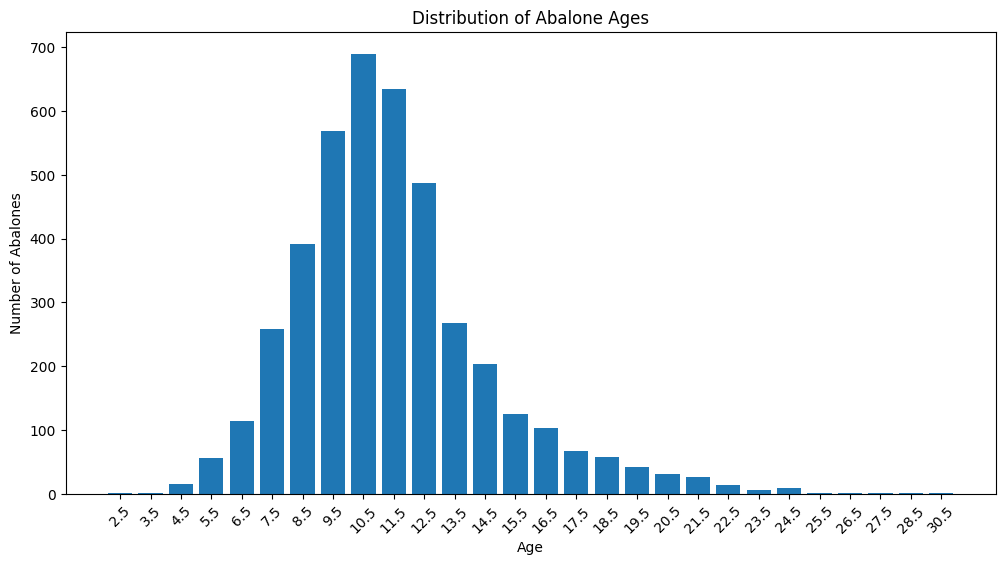

In [ ]:
rings = y['Rings']
age = rings + 1.5
age_counts = age.value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(age_counts.index.astype(str), age_counts.values)

plt.xlabel('Age')
plt.ylabel('Number of Abalones')
plt.title('Distribution of Abalone Ages')

plt.xticks(rotation=45)

plt.show()

Convert abalone sex feature to One-Hot Encoding

In [ ]:
X = pd.get_dummies(X, columns=['Sex'])
print("="*30 + " After converted " + "="*30 )
display(X.head())
print(X.columns)

============================== After converted ==============================


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,False,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,False,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,True,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,False,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,False,True,False


Index(['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')


split dataset (prevent model memorize data instead of training)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("="*30 + " After split dataset " + "="*30 )
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

============================== After split dataset ==============================
X_train shape: (3341, 10)
X_test shape: (836, 10)
y_train shape: (3341, 1)
y_test shape: (836, 1)


standardization (Avoid data with excessive differences affecting training)

In [ ]:
num_cols = [
    'Length', 'Diameter', 'Height',
    'Whole_weight', 'Shucked_weight',
    'Viscera_weight', 'Shell_weight'
]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

get raw dataset for Random Forest and XGBoost

In [ ]:
X_train_raw, X_test_raw = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

Convert back to DataFrame

In [ ]:
X_train = pd.DataFrame(
    X_train,
    columns=X.columns
)
X_test = pd.DataFrame(
    X_test,
    columns=X.columns
)
X_train_raw = pd.DataFrame(
    X_train_raw,
    columns=X.columns
)
X_test_raw = pd.DataFrame(
    X_test_raw,
    columns=X.columns
)

Export CSV Files

Scaled Data

In [ ]:
X_train.to_csv("X_train_scaled.csv", index=False)
X_test.to_csv("X_test_scaled.csv", index=False)

Unscaled Data

In [ ]:
X_train_raw.to_csv("X_train_raw.csv", index=False)
X_test_raw.to_csv("X_test_raw.csv", index=False)

Target Data

In [ ]:
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("=" * 30 + " CSV Export Completed " + "=" * 30)

============================== CSV Export Completed ==============================
